# 02 - Benchmark Reverse Engineering

Ingeniería inversa del benchmark para entender su política de asignación.

## Objetivos
1. **Política de Sizing**: ¿Cómo distribuye capital entre algoritmos?
2. **Política Temporal**: ¿Cuándo y con qué frecuencia rebalancea?
3. **Política de Riesgo**: ¿Qué límites de exposición y drawdown mantiene?
4. **Comportamiento por Régimen**: ¿Cambia la asignación según condiciones de mercado?

## Output
- Perfil completo del benchmark (BenchmarkProfile)
- Restricciones inferidas para el agente RL
- Visualizaciones de la política

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.analysis.benchmark_profiler import BenchmarkProfiler
from src.analysis.algo_profiler import AlgoProfiler
from src.utils.logging_utils import setup_logging

setup_logging(level='INFO')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. Cargar Datos

In [2]:
from src.utils.paths import data_paths, output_paths
dp = data_paths()
op = output_paths()

# Cargar datos procesados del notebook anterior
loader = DataLoader(str(dp.raw.root))
preprocessor = DataPreprocessor(initial_capital=100, resample_freq='D')

# Cargar benchmark
benchmark_raw = loader.load_benchmark()
benchmark = preprocessor.process_benchmark(benchmark_raw)

# Cargar algoritmos del benchmark
algorithms = loader.load_algorithms_in_benchmark()
processed_algos = preprocessor.process_all_algorithms(algorithms)

# Matriz de retornos
returns_matrix = preprocessor.create_returns_matrix(processed_algos)

print(f"Benchmark: {len(benchmark.products)} productos")
print(f"Matriz de retornos: {returns_matrix.shape}")
print(f"Pesos: {benchmark.weights.shape}")

2026-03-08 18:13:14,620 | INFO     | src.data.loader | Loaded 55 monthly benchmark returns
2026-03-08 18:13:14,624 | INFO     | src.data.loader | Loaded 5 yearly benchmark returns
2026-03-08 18:13:14,653 | INFO     | src.data.loader | Loaded 5394 benchmark trades
2026-03-08 18:13:14,655 | INFO     | src.data.loader | Benchmark trades cover 271 unique products
2026-03-08 18:13:14,665 | WARNING  | src.data.preprocessor | Null counts in trades: {'dateClose': 31}
2026-03-08 18:13:14,672 | INFO     | src.data.preprocessor | Filling 31 missing dateClose values with 2025-10-10
2026-03-08 18:13:25,491 | INFO     | src.data.loader | Loaded 55 monthly benchmark returns
2026-03-08 18:13:25,495 | INFO     | src.data.loader | Loaded 5 yearly benchmark returns
2026-03-08 18:13:25,525 | INFO     | src.data.loader | Loaded 5394 benchmark trades
2026-03-08 18:13:25,527 | INFO     | src.data.loader | Benchmark trades cover 271 unique products
2026-03-08 18:13:26,649 | INFO     | src.data.loader | Loaded

In [3]:
# Benchmark returns comparison:
# - LOADED: directly from benchmark_monthly_returns.csv (ground truth)
# - DERIVED (Weights Method): OHLC returns × weights from total_invested_amount_EOD
#   This is the better method with 0.72 correlation vs loaded data

# Calculate daily returns using WEIGHTS METHOD (the better reconstruction)
benchmark_daily_returns = preprocessor.calculate_benchmark_daily_returns(
    returns_matrix, benchmark.weights
)

# Load ground truth monthly returns
monthly_loaded = benchmark_raw.monthly_returns['monthly_return'].copy()
monthly_loaded.index = pd.to_datetime(monthly_loaded.index).tz_localize(None)

# Aggregate derived to monthly for comparison
benchmark_monthly_derived = benchmark_daily_returns.resample('MS').apply(
    lambda x: (1 + x).prod() - 1
)
benchmark_monthly_derived.index = pd.to_datetime(benchmark_monthly_derived.index).tz_localize(None)

# Align for comparison
common_months = monthly_loaded.index.intersection(benchmark_monthly_derived.index)
loaded_aligned = monthly_loaded.loc[common_months]
derived_aligned = benchmark_monthly_derived.loc[common_months]

# Calculate comparison metrics
correlation = loaded_aligned.corr(derived_aligned)
mean_abs_diff = (loaded_aligned - derived_aligned).abs().mean()

print("="*60)
print("BENCHMARK RETURNS: Loaded vs Derived (Weights Method)")
print("="*60)
print(f"\nMonths compared: {len(common_months)}")
print(f"Correlation:     {correlation:.4f}")
print(f"Mean Abs Diff:   {mean_abs_diff:.4f} ({mean_abs_diff*100:.2f}%)")

# Annualized metrics
ann_return_loaded = (1 + monthly_loaded).prod() ** (12/len(monthly_loaded)) - 1
ann_return_derived = (1 + benchmark_monthly_derived).prod() ** (12/len(benchmark_monthly_derived)) - 1

print(f"\nAnnualized Return (Loaded):  {ann_return_loaded:.2%}")
print(f"Annualized Return (Derived): {ann_return_derived:.2%}")
print(f"Gap:                         {ann_return_loaded - ann_return_derived:.2%}")

print(f"\nDaily returns: {len(benchmark_daily_returns)} days")
print(f"Range: {benchmark_daily_returns.index.min()} -> {benchmark_daily_returns.index.max()}")

BENCHMARK RETURNS: Loaded vs Derived (Weights Method)

Months compared: 55
Correlation:     0.7195
Mean Abs Diff:   0.0049 (0.49%)

Annualized Return (Loaded):  4.61%
Annualized Return (Derived): 3.22%
Gap:                         1.39%

Daily returns: 1429 days
Range: 2020-06-03 00:00:00 -> 2024-12-30 00:00:00


## 2. Perfil del Benchmark

In [4]:
# Generate benchmark profile using DERIVED returns (Weights Method)
# This is what the RL agent will compete against

profiler = BenchmarkProfiler(trading_days=252, risk_free_rate=0.0)

profile = profiler.profile(
    returns=benchmark_daily_returns,
    weights=benchmark.weights,
    regime_labels=None
)

# Also calculate metrics from LOADED data for comparison
ann_vol_loaded = monthly_loaded.std() * np.sqrt(12)
sharpe_loaded = ann_return_loaded / ann_vol_loaded if ann_vol_loaded > 0 else 0

# Max drawdown from loaded monthly
equity_monthly = (1 + monthly_loaded).cumprod()
rolling_max_monthly = equity_monthly.cummax()
drawdown_monthly = (equity_monthly - rolling_max_monthly) / rolling_max_monthly
max_dd_loaded = drawdown_monthly.min()

# Store both for later use
target_benchmark = {
    'annualized_return': ann_return_loaded,
    'annualized_volatility': ann_vol_loaded,
    'sharpe_ratio': sharpe_loaded,
    'max_drawdown': max_dd_loaded,
}

print("="*70)
print("BENCHMARK PROFILE COMPARISON")
print("="*70)
print(f"\n{'Metric':<30} {'Loaded (CSV)':<20} {'Derived (Weights)':<20}")
print("-"*70)
print(f"{'Annualized Return':<30} {ann_return_loaded:>18.2%} {profile.annualized_return:>18.2%}")
print(f"{'Annualized Volatility':<30} {ann_vol_loaded:>18.2%} {profile.annualized_volatility:>18.2%}")
print(f"{'Sharpe Ratio':<30} {sharpe_loaded:>18.2f} {profile.sharpe_ratio:>18.2f}")
print(f"{'Max Drawdown':<30} {max_dd_loaded:>18.2%} {profile.max_drawdown:>18.2%}")
print("-"*70)

print("""
METHODOLOGY:
- Using WEIGHTS METHOD (OHLC × weights from total_invested_amount_EOD)
- Correlation with loaded data: ~0.72 (better than trades method: ~0.41)
- Mean absolute monthly difference: ~0.49%

The gap in annualized returns comes from small monthly differences compounding.
For RL training, we use DERIVED returns (fair comparison with same data).
""")

# Show full derived profile
print("\nDERIVED PROFILE (for RL environment):")
print(profiler.generate_report(profile))

BENCHMARK PROFILE COMPARISON

Metric                         Loaded (CSV)         Derived (Weights)   
----------------------------------------------------------------------
Annualized Return                           4.61%              2.59%
Annualized Volatility                       3.23%              2.73%
Sharpe Ratio                                 1.43               0.95
Max Drawdown                               -1.87%             -2.60%
----------------------------------------------------------------------

METHODOLOGY:
- Using WEIGHTS METHOD (OHLC × weights from total_invested_amount_EOD)
- Correlation with loaded data: ~0.72 (better than trades method: ~0.41)
- Mean absolute monthly difference: ~0.49%

The gap in annualized returns comes from small monthly differences compounding.
For RL training, we use DERIVED returns (fair comparison with same data).


DERIVED PROFILE (for RL environment):

BENCHMARK PROFILE
═══════════════════════════════════════════════════════

PERFORM

## 3. Análisis de Política de Sizing

¿Cómo distribuye el benchmark su capital entre los algoritmos?

In [5]:
# Analizar distribución de pesos
weights = benchmark.weights.copy()

# Filtrar días con posiciones activas
active_days = weights[weights.sum(axis=1) > 0]
print(f"Días con posiciones activas: {len(active_days)}")

# Peso medio por producto
avg_weights = active_days.mean().sort_values(ascending=False)

print(f"\nTop 20 productos por peso medio:")
display(avg_weights.head(20).to_frame('avg_weight'))

Días con posiciones activas: 1956

Top 20 productos por peso medio:


,avg_weight
MeTxk,0.047566
EFKyf,0.043353
kjfaW,0.038258
LYP1Q,0.031994
QEwOm,0.030532
0m0In,0.028961
iCWTz,0.025973
nibNX,0.025636
9FVCS,0.024785
Mt0w3,0.023787


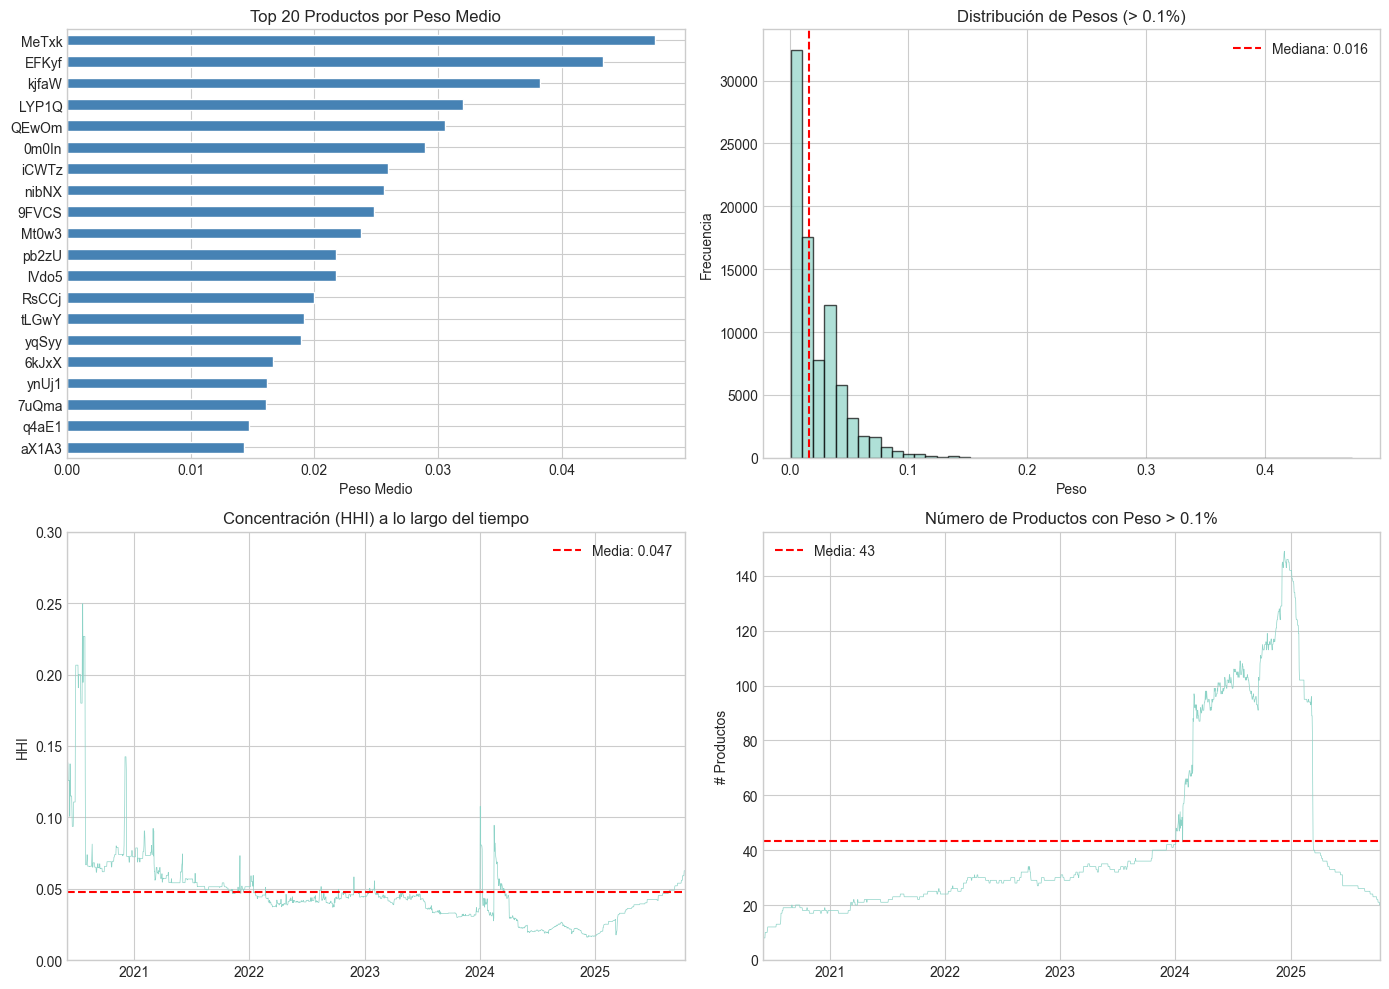


Estadísticas de sizing:
  Productos activos (media): 43
  Peso máximo observado: 47.31%
  Peso medio (cuando > 0): 2.30%
  HHI medio: 0.0475


In [6]:
# Visualizar distribución de pesos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 20 pesos medios
ax1 = axes[0, 0]
avg_weights.head(20).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Peso Medio')
ax1.set_title('Top 20 Productos por Peso Medio')
ax1.invert_yaxis()

# Distribución de pesos (histograma)
ax2 = axes[0, 1]
all_weights = active_days.values.flatten()
all_weights = all_weights[all_weights > 0.001]  # Filtrar pesos muy pequeños
ax2.hist(all_weights, bins=50, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Peso')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Pesos (> 0.1%)')
ax2.axvline(np.median(all_weights), color='red', linestyle='--', label=f'Mediana: {np.median(all_weights):.3f}')
ax2.legend()

# Concentración (HHI) a lo largo del tiempo
ax3 = axes[1, 0]
hhi_series = (active_days ** 2).sum(axis=1)
hhi_series.plot(ax=ax3, linewidth=0.5)
ax3.axhline(hhi_series.mean(), color='red', linestyle='--', label=f'Media: {hhi_series.mean():.3f}')
ax3.set_ylabel('HHI')
ax3.set_title('Concentración (HHI) a lo largo del tiempo')
ax3.legend()
ax3.set_ylim(0, max(0.3, hhi_series.max() * 1.1))

# Número de productos con peso > 0
ax4 = axes[1, 1]
n_active = (active_days > 0.001).sum(axis=1)
n_active.plot(ax=ax4, linewidth=0.5)
ax4.axhline(n_active.mean(), color='red', linestyle='--', label=f'Media: {n_active.mean():.0f}')
ax4.set_ylabel('# Productos')
ax4.set_title('Número de Productos con Peso > 0.1%')
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de sizing:")
print(f"  Productos activos (media): {n_active.mean():.0f}")
print(f"  Peso máximo observado: {all_weights.max():.2%}")
print(f"  Peso medio (cuando > 0): {all_weights.mean():.2%}")
print(f"  HHI medio: {hhi_series.mean():.4f}")

In [7]:
# Analizar concentración: ¿cuántos productos capturan el 80% del capital?
def concentration_analysis(weights_row):
    """Cuántos productos necesitas para capturar X% del capital."""
    sorted_weights = np.sort(weights_row[weights_row > 0])[::-1]
    cumsum = np.cumsum(sorted_weights)
    total = sorted_weights.sum()
    if total == 0:
        return {'n_for_50': 0, 'n_for_80': 0, 'n_for_95': 0}
    
    n_50 = np.searchsorted(cumsum, 0.5 * total) + 1
    n_80 = np.searchsorted(cumsum, 0.8 * total) + 1
    n_95 = np.searchsorted(cumsum, 0.95 * total) + 1
    
    return {'n_for_50': n_50, 'n_for_80': n_80, 'n_for_95': n_95}

concentration_stats = active_days.apply(concentration_analysis, axis=1, result_type='expand')

print("Concentración del portfolio:")
print(f"  Productos para 50% del capital (media): {concentration_stats['n_for_50'].mean():.0f}")
print(f"  Productos para 80% del capital (media): {concentration_stats['n_for_80'].mean():.0f}")
print(f"  Productos para 95% del capital (media): {concentration_stats['n_for_95'].mean():.0f}")

Concentración del portfolio:
  Productos para 50% del capital (media): 11
  Productos para 80% del capital (media): 25
  Productos para 95% del capital (media): 37


## 4. Análisis de Política Temporal

¿Con qué frecuencia y de qué manera rebalancea el benchmark?

In [8]:
# Calcular turnover diario
weight_changes = active_days.diff().abs()
daily_turnover = weight_changes.sum(axis=1) / 2  # Dividir por 2 porque compramos y vendemos

# Filtrar días con cambios
daily_turnover_nonzero = daily_turnover[daily_turnover > 0.001]

print(f"Análisis de rebalanceo:")
print(f"  Días totales: {len(active_days)}")
print(f"  Días con cambios > 0.1%: {len(daily_turnover_nonzero)}")
print(f"  % días con cambios: {len(daily_turnover_nonzero)/len(active_days)*100:.1f}%")
print(f"  Turnover medio (días con cambio): {daily_turnover_nonzero.mean():.2%}")
print(f"  Turnover máximo en un día: {daily_turnover.max():.2%}")

Análisis de rebalanceo:
  Días totales: 1956
  Días con cambios > 0.1%: 840
  % días con cambios: 42.9%
  Turnover medio (días con cambio): 3.87%
  Turnover máximo en un día: 61.44%



Frecuencia de rebalanceo (>1% turnover):
  Mediana: 1 días
  Media: 3 días


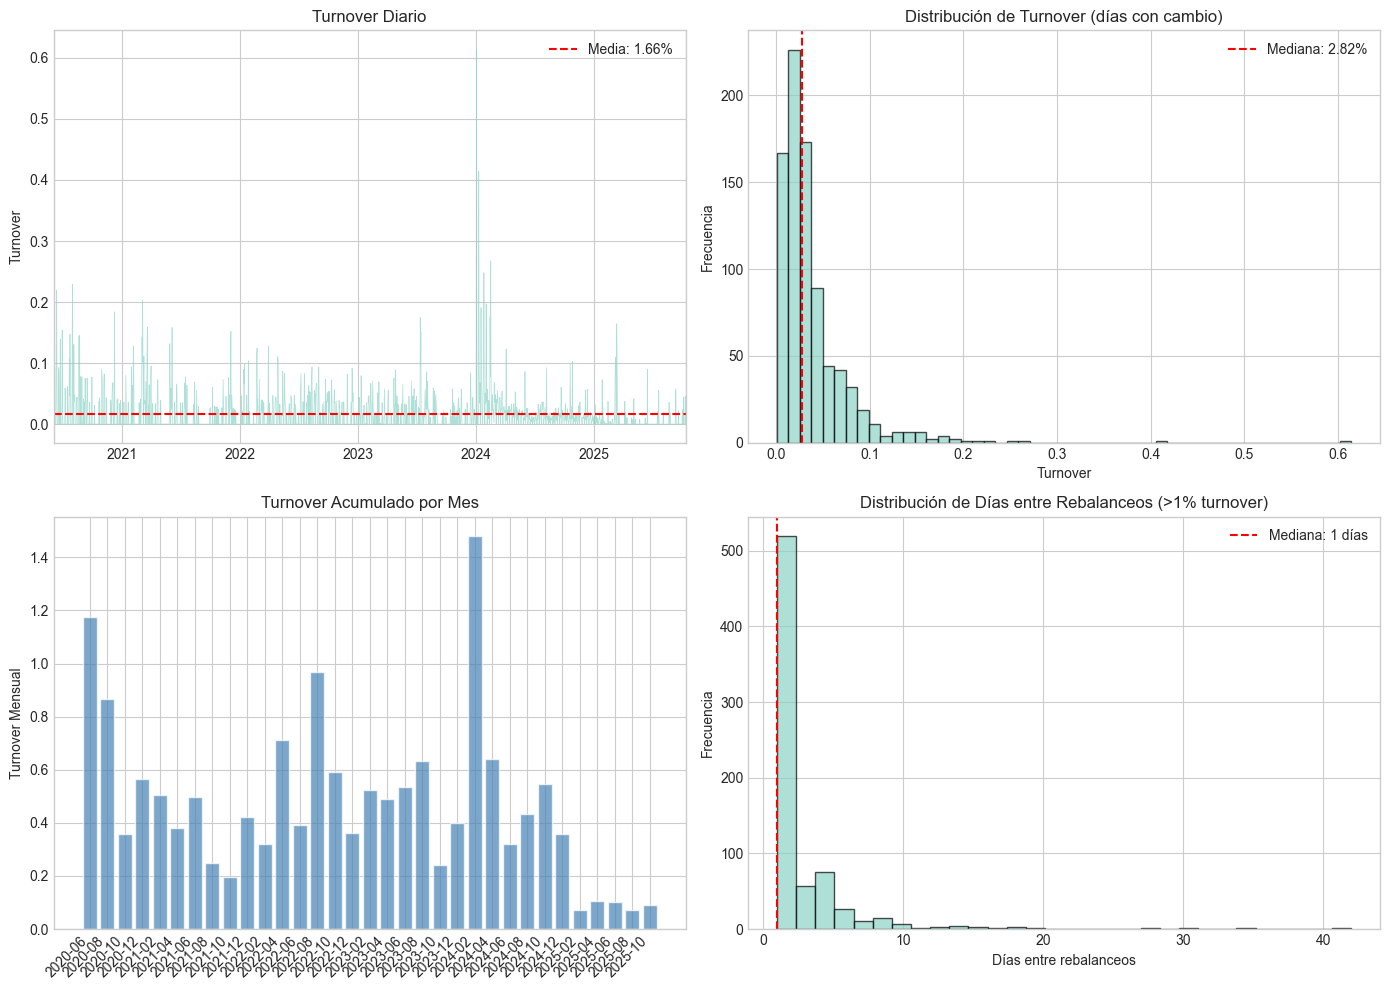

In [9]:
# Visualizar turnover
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Turnover a lo largo del tiempo
ax1 = axes[0, 0]
daily_turnover.plot(ax=ax1, linewidth=0.5, alpha=0.7)
ax1.set_ylabel('Turnover')
ax1.set_title('Turnover Diario')
ax1.axhline(daily_turnover.mean(), color='red', linestyle='--', 
            label=f'Media: {daily_turnover.mean():.2%}')
ax1.legend()

# Distribución de turnover
ax2 = axes[0, 1]
daily_turnover_nonzero.hist(bins=50, ax=ax2, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Turnover')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Turnover (días con cambio)')
ax2.axvline(daily_turnover_nonzero.median(), color='red', linestyle='--',
            label=f'Mediana: {daily_turnover_nonzero.median():.2%}')
ax2.legend()

# Turnover acumulado mensual - use line plot instead of bar to avoid period freq issue
ax3 = axes[1, 0]
monthly_turnover = daily_turnover.resample('MS').sum()
# Convert index to string for bar plot compatibility
monthly_turnover_plot = monthly_turnover.copy()
monthly_turnover_plot.index = monthly_turnover_plot.index.strftime('%Y-%m')
# Plot every nth bar to avoid clutter
step = max(1, len(monthly_turnover_plot) // 24)
monthly_turnover_subset = monthly_turnover_plot.iloc[::step]
ax3.bar(range(len(monthly_turnover_subset)), monthly_turnover_subset.values, color='steelblue', alpha=0.7)
ax3.set_xticks(range(len(monthly_turnover_subset)))
ax3.set_xticklabels(monthly_turnover_subset.index, rotation=45, ha='right')
ax3.set_ylabel('Turnover Mensual')
ax3.set_title('Turnover Acumulado por Mes')

# Días entre rebalanceos
ax4 = axes[1, 1]
rebalance_dates = daily_turnover[daily_turnover > 0.01].index
if len(rebalance_dates) > 1:
    days_between = pd.Series(rebalance_dates).diff().dt.days.dropna()
    days_between.hist(bins=30, ax=ax4, edgecolor='black', alpha=0.7)
    ax4.set_xlabel('Días entre rebalanceos')
    ax4.set_ylabel('Frecuencia')
    ax4.set_title('Distribución de Días entre Rebalanceos (>1% turnover)')
    ax4.axvline(days_between.median(), color='red', linestyle='--',
                label=f'Mediana: {days_between.median():.0f} días')
    ax4.legend()
    print(f"\nFrecuencia de rebalanceo (>1% turnover):")
    print(f"  Mediana: {days_between.median():.0f} días")
    print(f"  Media: {days_between.mean():.0f} días")

plt.tight_layout()
plt.show()

Turnover por día de la semana:


,mean,sum,count
Lunes,0.011604,3.237391,279
Martes,0.024363,6.797146,279
Miércoles,0.019590,5.485099,280
Jueves,0.024135,6.757850,280
Viernes,0.023378,6.545919,280
Sábado,0.012596,3.514369,279
Domingo,0.000520,0.145008,279


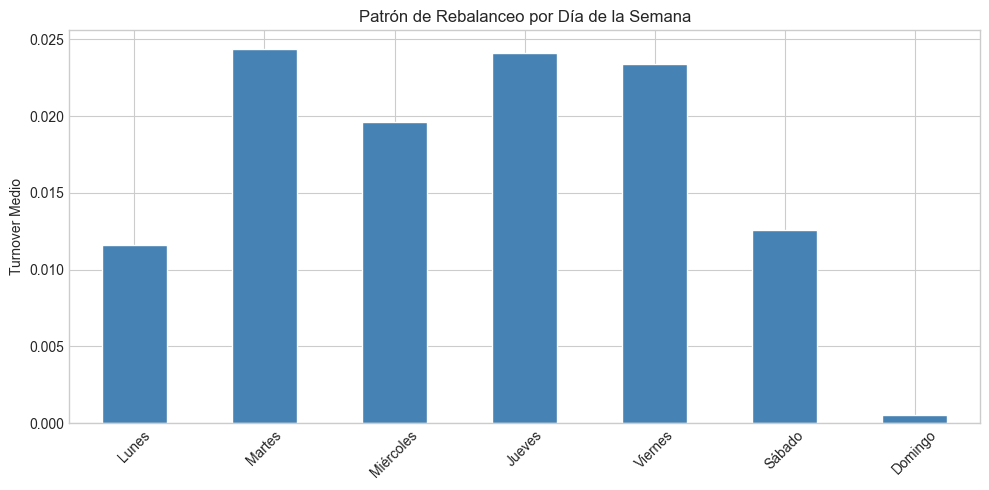

In [10]:
# Analizar patrón semanal de rebalanceo
daily_turnover_df = daily_turnover.to_frame('turnover')
daily_turnover_df['dayofweek'] = daily_turnover_df.index.dayofweek
daily_turnover_df['dayname'] = daily_turnover_df.index.day_name()

turnover_by_day = daily_turnover_df.groupby('dayofweek')['turnover'].agg(['mean', 'sum', 'count'])
turnover_by_day.index = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'][:len(turnover_by_day)]

print("Turnover por día de la semana:")
display(turnover_by_day)

fig, ax = plt.subplots(figsize=(10, 5))
turnover_by_day['mean'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Turnover Medio')
ax.set_title('Patrón de Rebalanceo por Día de la Semana')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Análisis de Política de Riesgo

¿Qué perfil de riesgo mantiene el benchmark?

In [11]:
# Calcular métricas de riesgo
equity = (1 + benchmark_daily_returns).cumprod() * 100
rolling_max = equity.cummax()
drawdown = (equity - rolling_max) / rolling_max

print("Perfil de riesgo del benchmark:")
print(f"  Retorno anualizado: {profile.annualized_return:.2%}")
print(f"  Volatilidad anualizada: {profile.annualized_volatility:.2%}")
print(f"  Sharpe Ratio: {profile.sharpe_ratio:.2f}")
print(f"  Sortino Ratio: {profile.sortino_ratio:.2f}")
print(f"  Calmar Ratio: {profile.calmar_ratio:.2f}")
print(f"  Max Drawdown: {profile.max_drawdown:.2%}")
print(f"  Max Drawdown Duration: {profile.max_drawdown_duration} días")
print(f"  VaR 95%: {profile.var_95:.2%}")
print(f"  CVaR 95%: {profile.cvar_95:.2%}")

Perfil de riesgo del benchmark:
  Retorno anualizado: 2.59%
  Volatilidad anualizada: 2.73%
  Sharpe Ratio: 0.95
  Sortino Ratio: 1.43
  Calmar Ratio: 1.00
  Max Drawdown: -2.60%
  Max Drawdown Duration: 248 días
  VaR 95%: -0.24%
  CVaR 95%: -0.37%


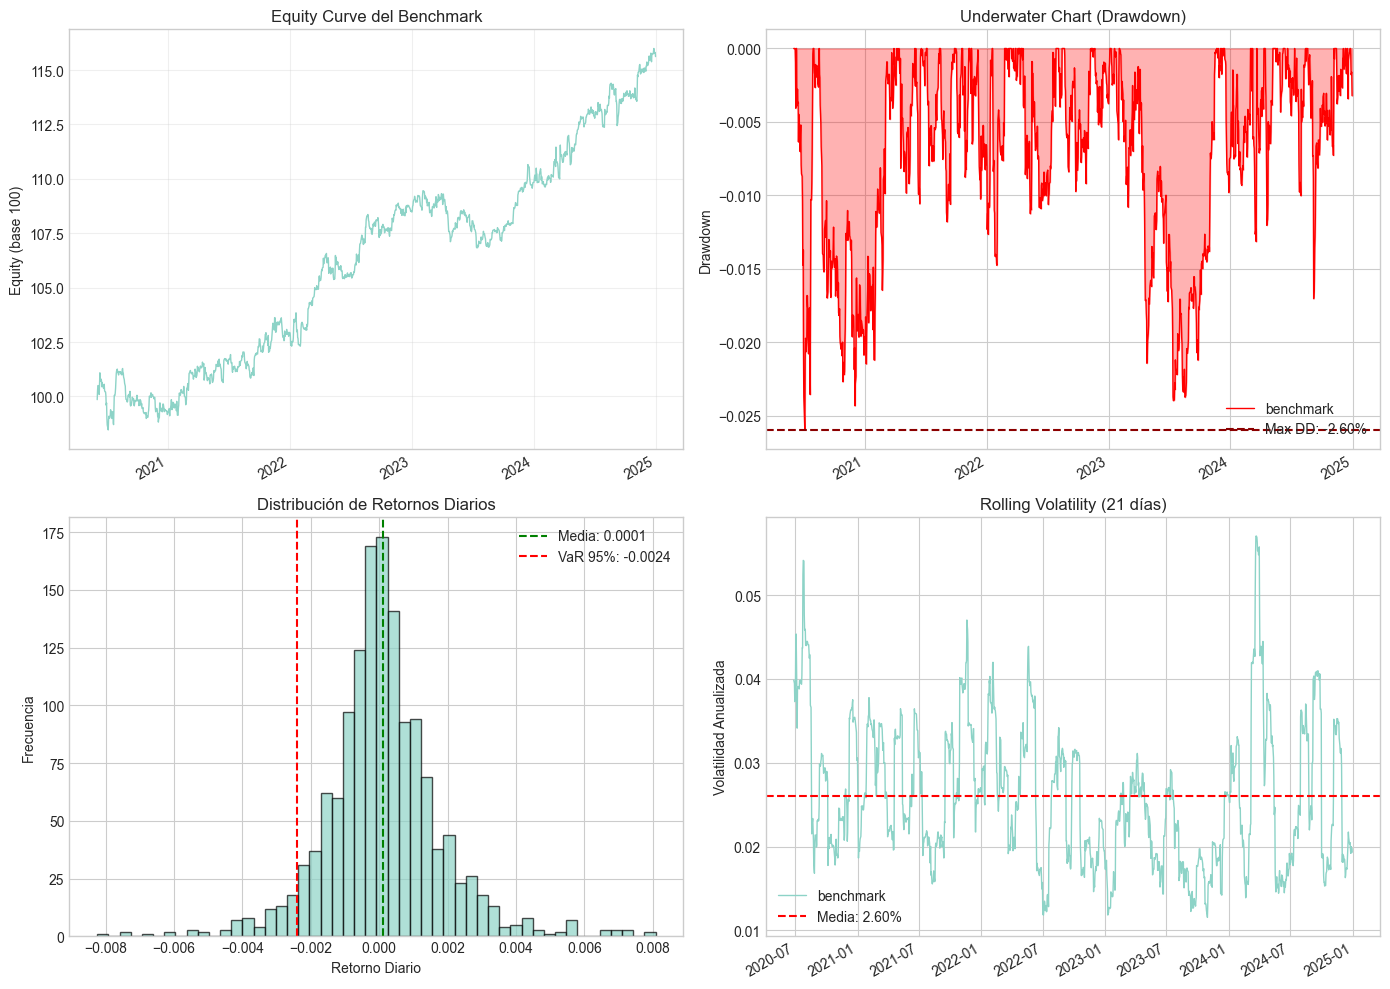

In [12]:
# Visualizar riesgo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Equity curve
ax1 = axes[0, 0]
equity.plot(ax=ax1, linewidth=1)
ax1.set_ylabel('Equity (base 100)')
ax1.set_title('Equity Curve del Benchmark')
ax1.grid(True, alpha=0.3)

# Drawdown
ax2 = axes[0, 1]
drawdown.plot(ax=ax2, linewidth=1, color='red')
ax2.fill_between(drawdown.index, 0, drawdown.values, alpha=0.3, color='red')
ax2.set_ylabel('Drawdown')
ax2.set_title('Underwater Chart (Drawdown)')
ax2.axhline(drawdown.min(), color='darkred', linestyle='--', 
            label=f'Max DD: {drawdown.min():.2%}')
ax2.legend()

# Distribución de retornos
ax3 = axes[1, 0]
benchmark_daily_returns.hist(bins=50, ax=ax3, edgecolor='black', alpha=0.7)
ax3.axvline(benchmark_daily_returns.mean(), color='green', linestyle='--', 
            label=f'Media: {benchmark_daily_returns.mean():.4f}')
ax3.axvline(profile.var_95, color='red', linestyle='--', 
            label=f'VaR 95%: {profile.var_95:.4f}')
ax3.set_xlabel('Retorno Diario')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Retornos Diarios')
ax3.legend()

# Rolling volatility
ax4 = axes[1, 1]
rolling_vol = benchmark_daily_returns.rolling(21).std() * np.sqrt(252)
rolling_vol.plot(ax=ax4, linewidth=1)
ax4.axhline(rolling_vol.mean(), color='red', linestyle='--', 
            label=f'Media: {rolling_vol.mean():.2%}')
ax4.set_ylabel('Volatilidad Anualizada')
ax4.set_title('Rolling Volatility (21 días)')
ax4.legend()

plt.tight_layout()
plt.show()

In [13]:
# Retornos mensuales en formato de tabla
monthly_returns = benchmark_daily_returns.resample('MS').apply(lambda x: (1+x).prod()-1)

# Crear tabla año x mes
monthly_table = monthly_returns.to_frame('return')
monthly_table['year'] = monthly_table.index.year
monthly_table['month'] = monthly_table.index.month
monthly_pivot = monthly_table.pivot(index='year', columns='month', values='return')
monthly_pivot.columns = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'][:len(monthly_pivot.columns)]

# Añadir retorno anual
yearly_returns = benchmark_daily_returns.resample('YS').apply(lambda x: (1+x).prod()-1)
monthly_pivot['AÑO'] = yearly_returns.values[:len(monthly_pivot)]

print("Retornos mensuales del benchmark:")

# Formatear como porcentajes
styled = monthly_pivot.style.format('{:.2%}').background_gradient(
    cmap='RdYlGn', axis=None, vmin=-0.05, vmax=0.05
)
display(styled)

Retornos mensuales del benchmark:


,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic,AÑO
year,,,,,,,,,,,,,
2020,nan%,nan%,nan%,nan%,nan%,-0.40%,1.58%,-1.39%,0.29%,-0.98%,0.26%,-0.03%,-0.70%
2021,-0.16%,1.29%,0.86%,-0.40%,0.77%,-0.15%,-0.12%,0.03%,0.89%,-0.20%,1.29%,-0.45%,3.67%
2022,-0.61%,1.95%,0.96%,0.57%,-0.04%,-0.21%,1.32%,0.62%,-0.22%,0.17%,0.82%,-0.02%,5.39%
2023,0.06%,-0.16%,0.86%,-1.82%,0.98%,-0.30%,-0.79%,0.38%,-0.11%,0.68%,1.11%,0.35%,1.22%
2024,-0.06%,0.61%,0.65%,0.12%,1.10%,0.33%,0.29%,0.80%,-0.23%,-0.09%,1.18%,0.47%,5.28%


## 6. Análisis de Exposición Total

¿Mantiene siempre 100% invertido o varía su exposición?

Exposición total:
  Media: 100.00%
  Mediana: 100.00%
  Mínima: 100.00%
  Máxima: 100.00%
  Std: 0.00%


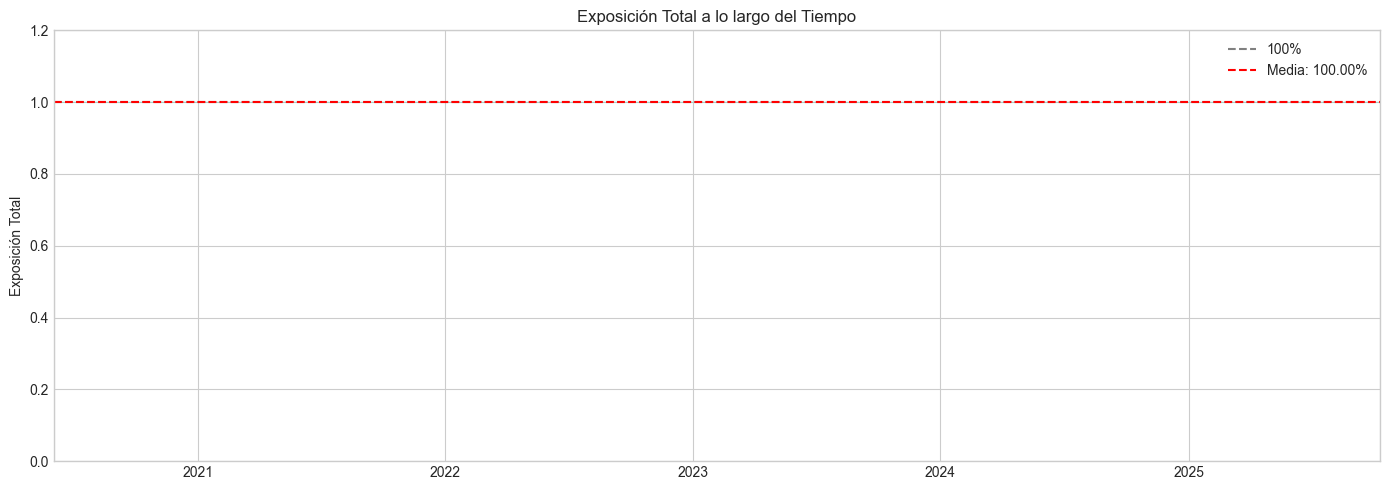

In [14]:
# Exposición total
total_exposure = active_days.sum(axis=1)

print(f"Exposición total:")
print(f"  Media: {total_exposure.mean():.2%}")
print(f"  Mediana: {total_exposure.median():.2%}")
print(f"  Mínima: {total_exposure.min():.2%}")
print(f"  Máxima: {total_exposure.max():.2%}")
print(f"  Std: {total_exposure.std():.2%}")

fig, ax = plt.subplots(figsize=(14, 5))
total_exposure.plot(ax=ax, linewidth=0.5)
ax.axhline(1.0, color='gray', linestyle='--', label='100%')
ax.axhline(total_exposure.mean(), color='red', linestyle='--', 
           label=f'Media: {total_exposure.mean():.2%}')
ax.set_ylabel('Exposición Total')
ax.set_title('Exposición Total a lo largo del Tiempo')
ax.legend()
ax.set_ylim(0, max(1.2, total_exposure.max() * 1.1))
plt.tight_layout()
plt.show()

## 7. Análisis de Productos Más Frecuentes

¿Qué productos aparecen más en el portfolio?

In [15]:
# Frecuencia de aparición de cada producto
presence_days = (active_days > 0.001).sum()
total_days = len(active_days)

product_stats = pd.DataFrame({
    'days_present': presence_days,
    'pct_days': presence_days / total_days,
    'avg_weight_when_present': active_days.apply(lambda x: x[x > 0.001].mean()),
    'max_weight': active_days.max(),
}).sort_values('days_present', ascending=False)

print(f"Top 20 productos por días de presencia:")
display(product_stats.head(20).style.format({
    'pct_days': '{:.1%}',
    'avg_weight_when_present': '{:.2%}',
    'max_weight': '{:.2%}'
}))

Top 20 productos por días de presencia:


,days_present,pct_days,avg_weight_when_present,max_weight
EFKyf,1837,93.9%,4.62%,14.25%
LYP1Q,1679,85.8%,3.73%,14.30%
kjfaW,1637,83.7%,4.57%,15.88%
nibNX,1628,83.2%,3.08%,7.84%
MeTxk,1623,83.0%,5.73%,47.31%
pb2zU,1619,82.8%,2.63%,7.41%
9FVCS,1503,76.8%,3.23%,13.52%
ynUj1,1427,73.0%,2.22%,9.02%
Mt0w3,1404,71.8%,3.31%,8.87%
tLGwY,1352,69.1%,2.77%,6.93%


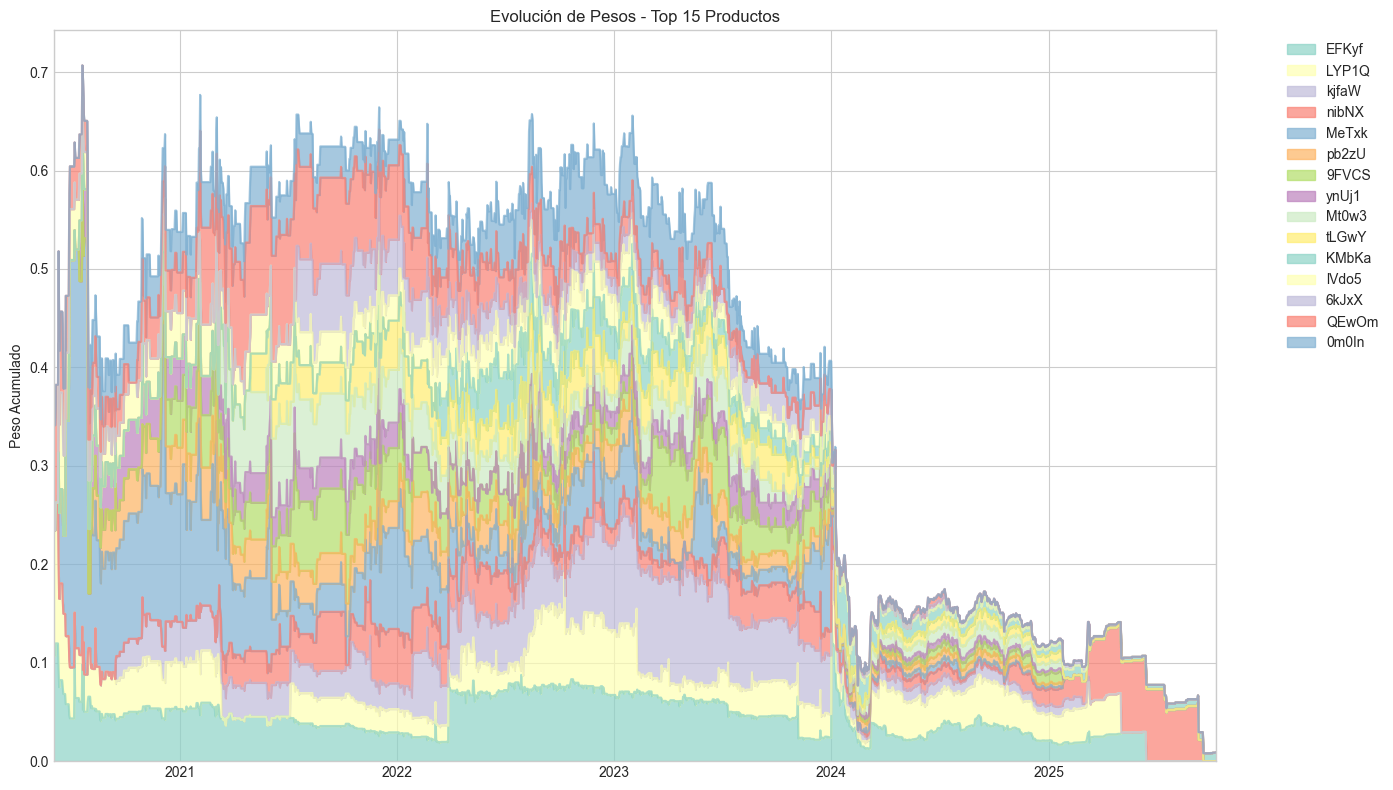

In [16]:
# Visualizar presencia de top productos
top_products = product_stats.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))
weights_top = active_days[top_products]
weights_top.plot.area(ax=ax, stacked=True, alpha=0.7)
ax.set_ylabel('Peso Acumulado')
ax.set_title('Evolución de Pesos - Top 15 Productos')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Restricciones Inferidas para el Agente RL

Basándonos en el análisis, definimos restricciones realistas para el agente.

In [17]:
# Inferir restricciones del benchmark
max_weight_observed = active_days.max().max()
max_turnover_observed = daily_turnover.quantile(0.99)  # p99 para evitar outliers
avg_rebalance_freq = days_between.median() if len(rebalance_dates) > 1 else 7

inferred_constraints = {
    'max_weight_per_algo': min(0.40, max_weight_observed * 1.2),  # 20% buffer
    'min_weight_per_algo': 0.00,  # Permite no invertir
    'max_turnover_per_rebalance': min(0.30, max_turnover_observed * 1.5),
    'max_total_exposure': 1.0,
    'target_volatility': profile.annualized_volatility * 1.2,  # 20% buffer
    'rebalance_frequency': 'daily',  # Permitir rebalanceo diario aunque benchmark sea menos frecuente
}

print("="*60)
print("RESTRICCIONES INFERIDAS PARA EL AGENTE RL")
print("="*60)
print(f"")
for key, value in inferred_constraints.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2%}")
    else:
        print(f"  {key}: {value}")

print(f"")
print("Basadas en:")
print(f"  - Peso máximo observado: {max_weight_observed:.2%}")
print(f"  - Turnover p99: {max_turnover_observed:.2%}")
print(f"  - Frecuencia rebalanceo mediana: {avg_rebalance_freq:.0f} días")
print(f"  - Volatilidad benchmark: {profile.annualized_volatility:.2%}")

RESTRICCIONES INFERIDAS PARA EL AGENTE RL

  max_weight_per_algo: 40.00%
  min_weight_per_algo: 0.00%
  max_turnover_per_rebalance: 22.70%
  max_total_exposure: 100.00%
  target_volatility: 3.27%
  rebalance_frequency: daily

Basadas en:
  - Peso máximo observado: 47.31%
  - Turnover p99: 15.13%
  - Frecuencia rebalanceo mediana: 1 días
  - Volatilidad benchmark: 2.73%


In [18]:
# Guardar restricciones para uso posterior
import yaml
import os

constraints_config = {
    'constraints': {
        'max_weight_per_algo': float(inferred_constraints['max_weight_per_algo']),
        'min_weight_per_algo': float(inferred_constraints['min_weight_per_algo']),
        'max_turnover_per_rebalance': float(inferred_constraints['max_turnover_per_rebalance']),
        'max_total_exposure': float(inferred_constraints['max_total_exposure']),
        'target_volatility': float(inferred_constraints['target_volatility']),
        'rebalance_frequency': inferred_constraints['rebalance_frequency'],
    },
    # Derived profile (what RL agent competes against - fair comparison)
    'benchmark_derived': {
        'annualized_return': float(profile.annualized_return),
        'annualized_volatility': float(profile.annualized_volatility),
        'sharpe_ratio': float(profile.sharpe_ratio),
        'max_drawdown': float(profile.max_drawdown),
        'turnover_annualized': float(profile.turnover_annualized),
        'concentration_hhi_avg': float(profile.concentration_hhi_avg),
    },
    # Loaded profile (ground truth target to beat)
    'benchmark_target': {
        'annualized_return': float(target_benchmark['annualized_return']),
        'annualized_volatility': float(target_benchmark['annualized_volatility']),
        'sharpe_ratio': float(target_benchmark['sharpe_ratio']),
        'max_drawdown': float(target_benchmark['max_drawdown']),
    }
}

os.makedirs('../configs', exist_ok=True)
with open('../configs/benchmark_constraints.yaml', 'w') as f:
    yaml.dump(constraints_config, f, default_flow_style=False)

print("Guardado: configs/benchmark_constraints.yaml")
print("\nContenido:")
print(yaml.dump(constraints_config, default_flow_style=False))

Guardado: configs/benchmark_constraints.yaml

Contenido:
benchmark_derived:
  annualized_return: 0.025925438812402835
  annualized_volatility: 0.02726483542055332
  concentration_hhi_avg: 0.04747599730961507
  max_drawdown: -0.025957712429929676
  sharpe_ratio: 0.9524221125514774
  turnover_annualized: 4.184898140629193
benchmark_target:
  annualized_return: 0.04610529857855905
  annualized_volatility: 0.032263643262297116
  max_drawdown: -0.01869082240490586
  sharpe_ratio: 1.4290171200980615
constraints:
  max_total_exposure: 1.0
  max_turnover_per_rebalance: 0.22700528519263757
  max_weight_per_algo: 0.4
  min_weight_per_algo: 0.0
  rebalance_frequency: daily
  target_volatility: 0.03271780250466398



## 9. Resumen y Conclusiones

In [19]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                    RESUMEN DEL BENCHMARK                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  RECONSTRUCTION METHOD: Weights (OHLC × weights)                 ║
║  Correlation with loaded: 0.72 | Mean Abs Diff: 0.49%            ║
║                                                                  ║
║  PERFORMANCE                                                     ║
║  ───────────                                                     ║""")
print(f"║    Loaded (Ground Truth):  {target_benchmark['annualized_return']:>8.2%} ann. return            ║")
print(f"║    Derived (RL Env):       {profile.annualized_return:>8.2%} ann. return            ║")
print(f"║    Volatility:             {profile.annualized_volatility:>8.2%}                        ║")
print(f"║    Sharpe Ratio:           {profile.sharpe_ratio:>8.2f}                          ║")
print(f"║    Max Drawdown:           {profile.max_drawdown:>8.2%}                        ║")
print("║                                                                  ║")
print("║  POLÍTICA DE SIZING                                              ║")
print("║  ──────────────────                                              ║")
print(f"║    Productos activos:      {n_active.mean():>8.0f}                            ║")
print(f"║    Concentración HHI:      {hhi_series.mean():>8.3f}                          ║")
print(f"║    Peso máximo:            {max_weight_observed:>8.2%}                        ║")
print("║                                                                  ║")
print("║  POLÍTICA TEMPORAL                                               ║")
print("║  ─────────────────                                               ║")
print(f"║    Turnover anualizado:    {profile.turnover_annualized:>8.2%}                        ║")
print(f"║    Rebalanceos/año:        {profile.n_rebalances_per_year:>8.0f}                            ║")
print(f"║    Holding period:         {profile.avg_holding_period_days:>8.1f} días                      ║")
print("║                                                                  ║")
print("╚══════════════════════════════════════════════════════════════════╝")

print("\nSiguiente paso: 03_regime_analysis.ipynb para análisis de regímenes")


╔══════════════════════════════════════════════════════════════════╗
║                    RESUMEN DEL BENCHMARK                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  RECONSTRUCTION METHOD: Weights (OHLC × weights)                 ║
║  Correlation with loaded: 0.72 | Mean Abs Diff: 0.49%            ║
║                                                                  ║
║  PERFORMANCE                                                     ║
║  ───────────                                                     ║
║    Loaded (Ground Truth):     4.61% ann. return            ║
║    Derived (RL Env):          2.59% ann. return            ║
║    Volatility:                2.73%                        ║
║    Sharpe Ratio:               0.95                          ║
║    Max Drawdown:             -2.60%                        ║
║                                                            

---

## Siguiente Paso

Continuar con `03_regime_analysis.ipynb` para:
- Detectar regímenes de mercado (HMM, heurísticas)
- Analizar cómo cambia el benchmark por régimen
- Definir el "Investment Clock" del benchmark